In [1]:
# ------------------------------------
# Save location for plots
# ------------------------------------
SAVE_DIR = './figures/pCAP_Gaussian'



# ------------------------------------
# Imports
# ------------------------------------
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import PillowWriter



# ------------------------------------
# Mathematical/logical functions
# ------------------------------------
def custom_even_tempered(start,number,contraction):
    list = []
    i = 0
    while i < number:
        list.append(start*(1/2)**(i/contraction))
        i+=1
    return list

def gaussian(x,alpha,beta):
    return beta*np.exp(-alpha*x**2)

def ovlp(x,left_psi,right_psi):
    return np.trapz(np.conj(left_psi)*right_psi,x)

def orthogonalize(x,basis):
    # Canonical orthogonalization algorithm
    N = len(basis)
    S = np.zeros((N,N))
    for i in range(N):
        for j in range(N):
            S[i,j] = ovlp(x,basis[i],basis[j])     
    s,U = np.linalg.eig(S)
    X = U@np.diag(s**(-0.5))@np.conj(U).T
    ortho_basis = []
    for i in range(N):
        ortho_basis.append(lin_comb(X.T[i],basis))
    return ortho_basis

def lin_comb(coeffs,vectors):
    psi = np.zeros(len(vectors[0]), dtype=complex)
    j = 0
    while j < len(vectors):
        psi += coeffs[j]*vectors[j]
        j+=1
    return psi

def T_ij(x,dx,psii,psij):
    # <psi_j|T|psi_i>
    scnd_deriv_psii = (-1/(2*dx**2))*(np.roll(psii, -1) + np.roll(psii, 1) - 2*psii)
    return np.trapz(np.conj(psij)*scnd_deriv_psii,x)

def V_ij(x,potential,psii,psij):
    # <psi_j|V|psi_i>
    return np.trapz(np.conj(psij)*potential*psii,x)

def H_ij(x,dx,potential,psii,psij):
    return T_ij(x,dx,psii,psij) + V_ij(x,potential,psii,psij)

def eta_traj(eta_list,H0,W_mat):
    N = len(H0[0])
    traj = []
    for i in H0[0]:
        traj.append([])
    for eta in eta_list:
        if len(traj[0]) == 0:
            Hcap = H0 - 1.0j*eta*W_mat
            Rw,Rv = np.linalg.eig(Hcap)
            Rw = Rw[np.argsort(Rw)]
            i = 0
            while i < N:
                traj[i].append(Rw[i])
                i+=1
        else:
            Hcap = H0 - 1.0j*eta*W_mat
            Rw,Rv = np.linalg.eig(Hcap)
            diff = np.zeros((N,N))
            for i in range(N):
                for j in range(N):
                    diff[i,j] = np.abs(np.real(Rw[j]) - np.real(traj[i][-1])) + np.abs(np.imag(Rw[j]) - np.imag(traj[i][-1]))
                traj[i].append(Rw[np.argsort(diff[i])[0]])
    return traj

def first_deriv(x,f):
    dx = x[1] - x[0]
    df = np.zeros_like(f)
    df[1:-1] = (f[2:] - f[:-2])/2
    df[0] = f[1] - f[0]
    df[-1] = f[-1] - f[-2]
    return df/dx

def log_vel(eta_list,state_traj):
    return eta_list*first_deriv(eta_list,state_traj)

def corr_log_vel(eta_list,state_traj):
    return 0.5*eta_list**2*first_deriv(eta_list,first_deriv(eta_list,state_traj))

def find_opt(low_eta,high_eta,eta_list,state_traj,corrected=False):
    if corrected == False:
        log_velocity = log_vel(eta_list,state_traj)
        abs_log_velocity = np.abs(log_vel(eta_list,state_traj))
        low_eta_idx = np.argsort(np.abs(eta_list - low_eta))[0]
        high_eta_idx = np.argsort(np.abs(eta_list - high_eta))[0]
        min_log_vel_idx = np.argsort(abs_log_velocity[low_eta_idx:high_eta_idx])[0] + low_eta_idx
        
        opt_eta = eta_list[min_log_vel_idx]
        opt_log_vel = log_velocity[min_log_vel_idx]

        real_E = np.real(state_traj[min_log_vel_idx])
        imag_E = np.imag(state_traj[min_log_vel_idx])
    elif corrected == True:
        corr_log_velocity = corr_log_vel(eta_list,state_traj)
        abs_corr_log_velocity = np.abs(corr_log_velocity)
        low_eta_idx = np.argsort(np.abs(eta_list - low_eta))[0]
        high_eta_idx = np.argsort(np.abs(eta_list - high_eta))[0]
        min_log_vel_idx = np.argsort(abs_corr_log_velocity[low_eta_idx:high_eta_idx])[0] + low_eta_idx

        opt_eta = eta_list[min_log_vel_idx]
        opt_log_vel = corr_log_velocity[min_log_vel_idx]
        
        corr_E = state_traj - log_vel(eta_list,state_traj)
        real_E = np.real(corr_E[min_log_vel_idx])
        imag_E = np.imag(corr_E[min_log_vel_idx])
    else:
        print('"corrected" parameter must be True or False')
    return opt_eta,opt_log_vel,real_E,imag_E

def color_spectrum(colors):
    list = []
    delta = 1/colors
    i = 0
    j = 0
    while j < colors:
        list.append(i)
        i+=delta
        j+=1
    spectrum = plt.cm.plasma(list)
    return spectrum

1. We begin by specifying the 1D space, including the boundaries (xmax, xmin) and the number of discrete points in space (N). N must be large enough to converge the properties of the resonance. Because N does not determine the size of the basis, it can be very large without significantly impacting computational cost.

In [2]:
# ------------------------------------
# Preparing 1D space
# ------------------------------------
N = 100000
xmax = 200
xmin = -200

dx = (xmax-xmin)/N
x = np.linspace(xmin,xmax,N)

2. We now prepare a potential energy surface that supports a metastable state (resonance). This potential features a well centered at zero. Dynamically, a particle placed in this well will tunnel out of the well over a finite period. However, we are interested in calculating the characteristic resonance energy and width of a particle in this system without using dynamics, instead treating the resonance as a stationary state with complex energy. This will be accomplished using a non-Hermitian approach called the projected complex absorbing potential (pCAP) method. This notebook is a faithful (albeit extremely simple) representation of the major computational steps performed by pCAP practitioners in electronic structure theory.

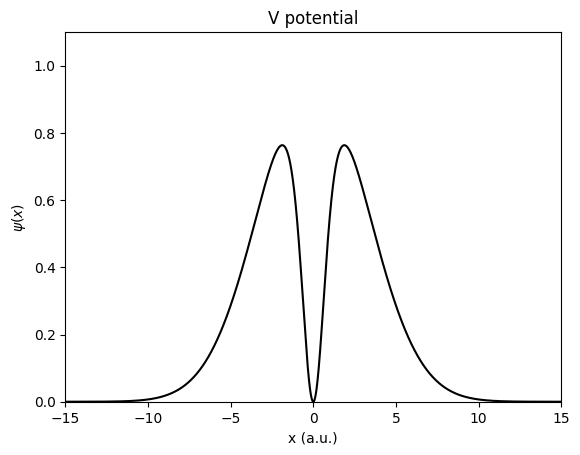

<Figure size 640x480 with 0 Axes>

In [3]:
# ------------------------------------
# Preparing potential surface
# ------------------------------------
def V(x):
    # A system supporting a single metastable state
    V0 = 1
    alpha = 0.05
    beta = 1
    return (1-V0/np.cosh(beta*x)**2)*np.exp(-alpha*x**2)

V_potential = V(x)



# ------------------------------------
# Plotting potential surface
# ------------------------------------
plt.xlabel('x (a.u.)')
plt.ylabel(r'$\psi(x)$')
plt.ylim(bottom=0,top=1.1)
plt.xlim(left=-15.0,right=15.0)
plt.plot(x,V_potential,color='black')
plt.title('V potential')
plt.savefig(os.path.join(SAVE_DIR,'V_potential.png'),dpi=300,format='png',bbox_inches='tight')
plt.show()
plt.clf()

3. We next prepare a Gaussian basis that is large enough to converge the properties of the resonance.

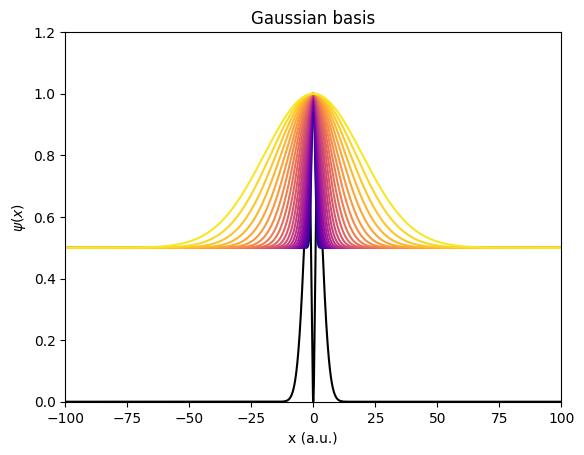

<Figure size 640x480 with 0 Axes>

In [4]:
# ------------------------------------
# Preparing Gaussian basis
# ------------------------------------
nbasis = 25
starting_alpha = 1
contraction_param = 2.5

alphas = custom_even_tempered(starting_alpha,nbasis,contraction_param)

basis = []
for alpha in alphas:
    basis.append(gaussian(x,alpha,beta=0.5))

colors = color_spectrum(nbasis)
plt.xlabel('x (a.u.)')
plt.ylabel(r'$\psi(x)$')
plt.xlim(left=-100.0,right=100.0)
plt.ylim(bottom=0,top=1.2)
plt.plot(x,V_potential,color='black')
i = 0
while i < nbasis:
     plt.plot(x,basis[i]+0.5,color=colors[i])
     i+=1
plt.title('Gaussian basis')
plt.savefig(os.path.join(SAVE_DIR,'Gaussian_basis.png'),dpi=300,format='png',bbox_inches='tight')
plt.show()
plt.clf()

4. We orthogonalize the Gaussian basis using a canonical orthogonalization algorthm.

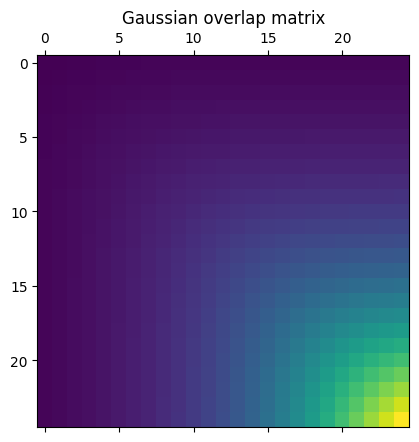

<Figure size 640x480 with 0 Axes>

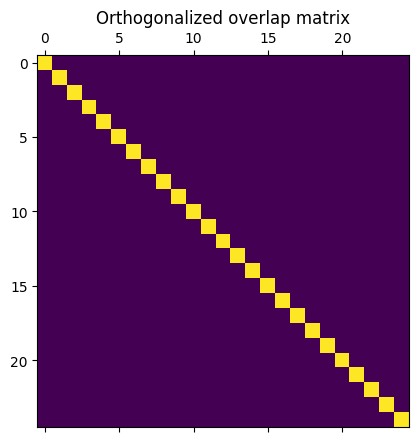

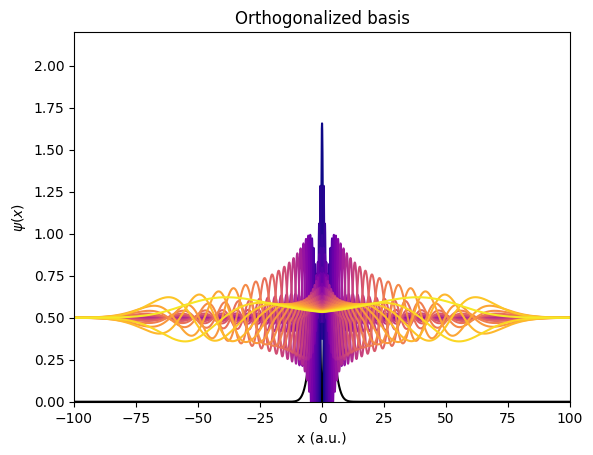

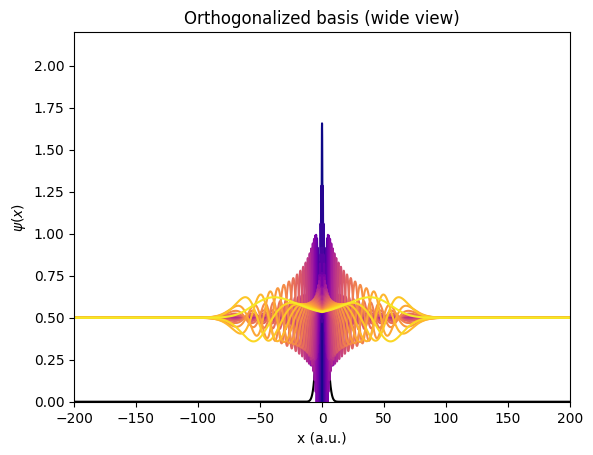

<Figure size 640x480 with 0 Axes>

In [5]:
# ------------------------------------
# Orthogonalizing Gaussian basis
# ------------------------------------
ortho_basis = np.real(orthogonalize(x,basis))



# ------------------------------------
# Plotting overlap matrices
# ------------------------------------
S_gaus = np.zeros((nbasis,nbasis))
for i in range(nbasis):
    for j in range(nbasis):
        S_gaus[i,j] = ovlp(x,basis[i],basis[j])

S_ortho = np.zeros((nbasis,nbasis))
for i in range(nbasis):
    for j in range(nbasis):
        S_ortho[i,j] = ovlp(x,ortho_basis[i],ortho_basis[j])

plt.matshow(S_gaus)
plt.title('Gaussian overlap matrix')
plt.savefig(os.path.join(SAVE_DIR,'Gaussian_ovlp.png'),dpi=300,format='png',bbox_inches='tight')
plt.show()
plt.clf()

plt.matshow(S_ortho)
plt.title('Orthogonalized overlap matrix')
plt.savefig(os.path.join(SAVE_DIR,'ortho_ovlp.png'),dpi=300,format='png',bbox_inches='tight')
plt.show()
plt.clf()



# ------------------------------------
# Plotting orthogonalized basis
# ------------------------------------
plt.xlabel('x (a.u.)')
plt.ylabel(r'$\psi(x)$')
plt.ylim(bottom=0,top=2.2)
plt.xlim(left=-100.0,right=100.0)
plt.plot(x,np.real(V_potential),color='black')
i = 0
while i < nbasis:
     plt.plot(x,np.real(ortho_basis[i]+0.5),color=colors[i])
     i+=1
plt.title('Orthogonalized basis')
plt.savefig(os.path.join(SAVE_DIR,'ortho_basis.png'),dpi=300,format='png',bbox_inches='tight')
plt.show()
plt.clf()

plt.xlabel('x (a.u.)')
plt.ylabel(r'$\psi(x)$')
plt.ylim(bottom=0,top=2.2)
plt.xlim(left=xmin,right=xmax)
plt.plot(x,np.real(V_potential),color='black')
i = 0
while i < nbasis:
     plt.plot(x,np.real(ortho_basis[i]+0.5),color=colors[i])
     i+=1
plt.title('Orthogonalized basis (wide view)')
plt.savefig(os.path.join(SAVE_DIR,'ortho_basis_wide.png'),dpi=300,format='png',bbox_inches='tight')
plt.show()
plt.clf()

5. We construct and diagonalize the system Hamiltonian in the orthogonal basis. This produces a set of discretized continuum eigenstates. At this point we must select a target eigenstate for the subsequent "eta-trajectory" calculations. While there is some amount of guesswork and intuition involved in this selection, the guiding principle is that the target eigenstate should resemble the expected resonance state, both with respect to its energy and wavefunction character. In this example, we expect that the resonance will be at about 0.464 au of energy and have large amplitude inside the well. Indeed, we observe an eigenstate at 0.458 au of energy that fits this description. The system Hamiltonian will be referred to as the zero-order Hamiltonian going forward because we will be perturbing this system with an imaginary absorbing potential in the subsequent steps.

State 1 Energy = 0.0008936708979739155 a.u.
State 2 Energy = 0.0036522962711846973 a.u.
State 3 Energy = 0.008519690562560425 a.u.
State 4 Energy = 0.01593915327885747 a.u.
State 5 Energy = 0.026610228602445028 a.u.
State 6 Energy = 0.0415710818866231 a.u.
State 7 Energy = 0.06230915773000966 a.u.
State 8 Energy = 0.09090094806731704 a.u.
State 9 Energy = 0.13017457381763586 a.u.
State 10 Energy = 0.18386999761626094 a.u.
State 11 Energy = 0.2567081649265509 a.u.
State 12 Energy = 0.35397399123389744 a.u.
State 13 Energy = 0.45803181008301846 a.u.
State 14 Energy = 0.492683607385216 a.u.
State 15 Energy = 0.6525667188245724 a.u.
State 16 Energy = 0.8604500133049167 a.u.
State 17 Energy = 1.1208632246160475 a.u.
State 18 Energy = 1.45580747725797 a.u.
State 19 Energy = 1.8983501607232174 a.u.
State 20 Energy = 2.4923808258687234 a.u.
State 21 Energy = 3.294182618942195 a.u.
State 22 Energy = 4.395003158099631 a.u.
State 23 Energy = 5.925044552009091 a.u.
State 24 Energy = 8.179667353847

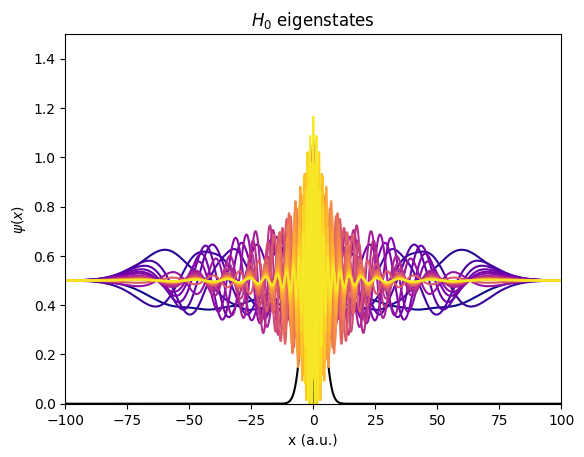

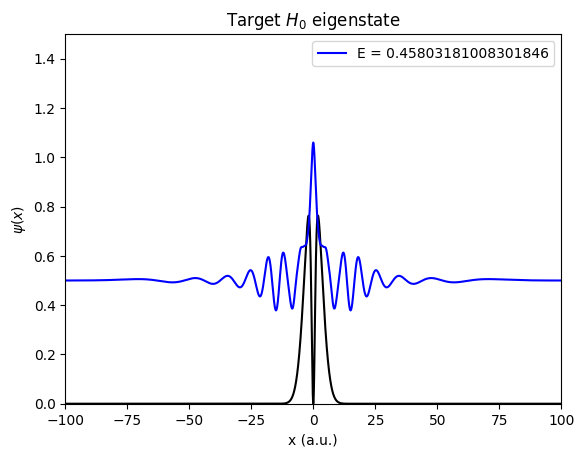

<Figure size 640x480 with 0 Axes>

In [6]:
# ------------------------------------
# Constructing zero-order Hamiltonian
# ------------------------------------
H = np.zeros((nbasis,nbasis))

for i in range(nbasis):
  for j in range(nbasis):
    H[i,j] = H_ij(x,dx,V_potential,ortho_basis[j],ortho_basis[i])



# ------------------------------------
# Diagonalizing zero-order Hamiltonian
# ------------------------------------
w,v = np.linalg.eig(H)

sorter = np.argsort(w)
w = w[sorter]
v = v.T
v = v[sorter]

i = 1
for E in w:
  print('State',i,'Energy =',E,'a.u.')
  i+=1



# ------------------------------------
# Calculating zero-order Hamiltonian eigenstates in 1D space
# ------------------------------------
psi = []
for coeffs in v:
  psi.append(lin_comb(coeffs,ortho_basis))



# ------------------------------------
# Plotting eigenstates
# ------------------------------------
plt.xlabel('x (a.u.)')
plt.ylabel(r'$\psi(x)$')
plt.ylim(bottom=0,top=1.5)
plt.xlim(left=-100.0,right=100.0)
plt.plot(x,V_potential,color='black')
i = 0
while i < nbasis:
     plt.plot(x,np.real(-psi[i]+0.5),color=colors[i])
     i+=1
plt.title(r'$H_{0}$ eigenstates')
plt.savefig(os.path.join(SAVE_DIR,'H0_eigenstates.png'),dpi=300,format='png',bbox_inches='tight')
plt.show()
plt.clf()

target_state = 13

plt.xlabel('x (a.u.)')
plt.ylabel(r'$\psi(x)$')
plt.ylim(bottom=0,top=1.5)
plt.xlim(left=-100.0,right=100.0)
plt.plot(x,V_potential,color='black')
plt.plot(x,np.real(-psi[target_state-1]+0.5),color='blue',label='E = '+str(w[12]))
plt.legend()
plt.title(r'Target $H_{0}$ eigenstate')
plt.savefig(os.path.join(SAVE_DIR,'H0_target_state.png'),dpi=300,format='png',bbox_inches='tight')
plt.show()
plt.clf()

6. [Runtime ~ 20 sec] We now prepare the CAP Hamiltonian in the basis of the zero-order eigenstates calculated above and perform an eta-trajectory analysis. The CAP Hamiltonian is the zero-order system Hamiltonian (which is diagonal in the basis of its own eigenstates) with a perturbation added. This perturbation is imaginary and is composed of an absorbing potential (-W) and a strength parameter (eta). The absorbing potential is zero in the region of the well (x = {-5,5}) and increases with x^2 outside it. The strength parameter, eta, scales this absorbing potential. The purpose of an eta-trajectory analysis is to determine an optimal value for eta: one which produces an accurate resonance energy and width. When eta = 0, the CAP Hamiltonian is just the system Hamiltonian and the eigenvalues (energies) are purely real. However, when eta is a finite positive number, the energies rotate into the complex plane. Producing eta trajectories involves plotting the eigenvalues of the CAP Hamiltonian in the complex plane, tracking how each individual eigenvalue moves within the complex plane as eta increases. An optimal eta value is determined by finding where the energy of the target eigenstate settles in the complex plane (looking for a stationary point, which corresponds to a minimum in the logarithmic velocity of the energy). Additionally, practitioners of pCAP theory often also calculate a "corrected" trajectory, which is included below.

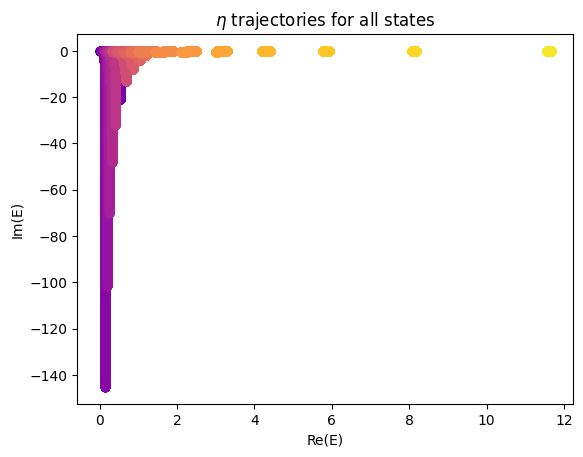

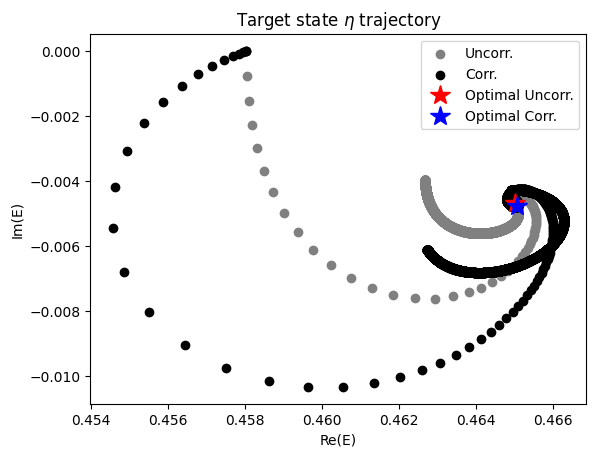

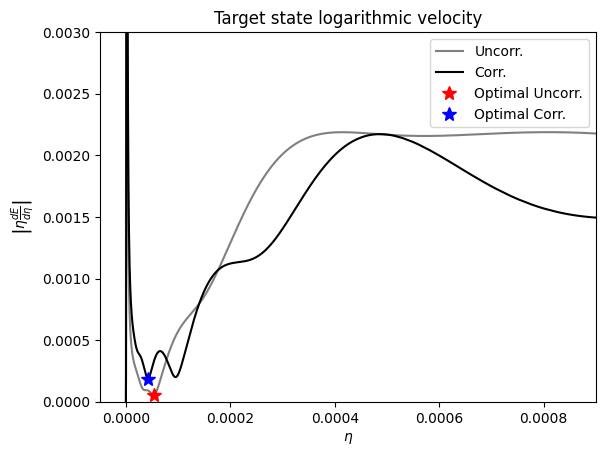

<Figure size 640x480 with 0 Axes>

In [7]:
# ------------------------------------
# Preparing CAP functional form
# ------------------------------------
def W(x):
    x_onset = 5
    return np.piecewise(x, [np.abs(x) < x_onset, np.abs(x) >= x_onset], [0, lambda x: (np.abs(x) - x_onset)**2])

W_potential = W(x)



# ------------------------------------
# Calculating eta trajectories
# ------------------------------------
H0 = np.zeros((nbasis,nbasis),dtype=complex)
W_mat = np.zeros((nbasis,nbasis),dtype=complex)

for i in range(nbasis):
    H0[i,i] = w[i]

for i in range(nbasis):
  for j in range(nbasis):
      W_mat[i,j] = np.trapz(np.conj(psi[i])*W_potential*psi[j])

eta_list = np.linspace(0,0.001,10000)

traj = eta_traj(eta_list,H0,W_mat)



# ------------------------------------
# Plotting all eta trajectories
# ------------------------------------
i = 0
for traj_i in traj:
    E = np.array(traj_i)
    plt.scatter(np.real(E),np.imag(E),color=colors[i])
    i+=1
plt.xlabel('Re(E)')
plt.ylabel('Im(E)')
plt.title(r'$\eta$ trajectories for all states')
plt.savefig(os.path.join(SAVE_DIR,'all_eta_traj.png'),dpi=300,format='png',bbox_inches='tight')
plt.show()
plt.clf()



# ------------------------------------
# Analyzing the eta trajectory of the target state
# ------------------------------------
opt_eta_search_space = [0.00001,0.0008]

E = np.array(traj[target_state-1])
log_velocity = log_vel(eta_list,E)

corr_E = E - log_velocity
corr_log_velocity = corr_log_vel(eta_list,E)

opt_eta, opt_log_vel, real_E, imag_E = find_opt(opt_eta_search_space[0],
                                             opt_eta_search_space[1],
                                             eta_list,
                                             E,
                                             corrected=False)

corr_opt_eta, corr_opt_log_vel, corr_real_E, corr_imag_E = find_opt(opt_eta_search_space[0],
                                                                 opt_eta_search_space[1],
                                                                 eta_list,
                                                                 E,
                                                                 corrected=True)



# ------------------------------------
# Plotting eta trajectory and logarithmic velocity of target state
# ------------------------------------
plt.scatter(np.real(E),np.imag(E),color='gray',label='Uncorr.')
plt.scatter(np.real(corr_E),np.imag(corr_E),color='black',label='Corr.')
plt.plot(real_E,imag_E,'r*',markersize=15,label='Optimal Uncorr.')
plt.plot(corr_real_E,corr_imag_E,'b*',markersize=15,label='Optimal Corr.')
plt.xlabel('Re(E)')
#plt.ylim(-2.5,0.1)
plt.ylabel('Im(E)')
plt.legend()
plt.title(r'Target state $\eta$ trajectory')
plt.savefig(os.path.join(SAVE_DIR,'target_eta_traj.png'),dpi=300,format='png',bbox_inches='tight')
plt.show()
plt.clf()

plt.plot(eta_list,np.abs(log_velocity),color='gray',label='Uncorr.')
plt.plot(eta_list,np.abs(corr_log_velocity),color='black',label='Corr.')
plt.plot(opt_eta,np.abs(opt_log_vel),'r*',markersize=10,label='Optimal Uncorr.')
plt.plot(corr_opt_eta,np.abs(corr_opt_log_vel),'b*',markersize=10,label='Optimal Corr.')
plt.xlim(-0.00005,0.0009)
plt.ylim(0,0.003)
plt.xlabel(r'$\eta$')
plt.ylabel(r'$\left|\eta\frac{dE}{d\eta}\right|$')
plt.legend()
plt.title('Target state logarithmic velocity')
plt.savefig(os.path.join(SAVE_DIR,'target_log_vel.png'),dpi=300,format='png',bbox_inches='tight')
plt.show()
plt.clf()

7. We now plot the resonance wavefunction and report the final results for the resonance: the uncorrected and corrected optimal eta, energy, and width.

---------- Uncorrected ----------
Optimal eta = 5.3305330533053305e-05
Energy = 0.4650153662504678 a.u.
Width = 0.00935799004439895 a.u.
---------- Corrected ----------
Optimal eta = 4.220422042204221e-05
Energy = 0.4650679791690104 a.u.
Width = 0.009541334511205282 a.u.


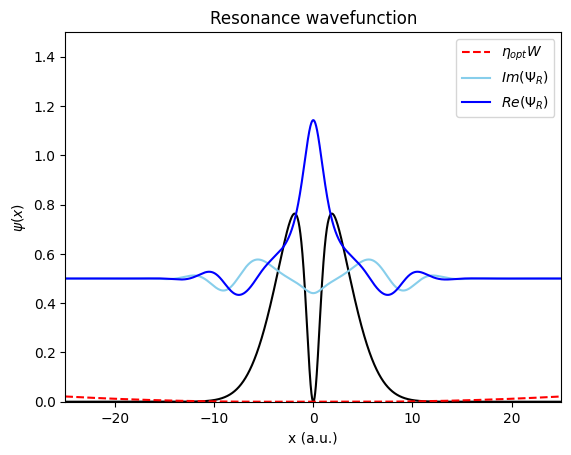

<Figure size 640x480 with 0 Axes>

In [8]:
# ------------------------------------
# Diagonalizing CAP Hamiltonian with optimal eta (to get resonance wavefunction)
# ------------------------------------
Hcap = H0 - 1.0j*opt_eta*W_mat
w_cap,v_cap = np.linalg.eig(Hcap)

resonance_idx = np.argsort(np.abs(np.real(w_cap) - real_E))[0]
resonance_wvfxn = lin_comb(v_cap.T[resonance_idx],psi)



# ------------------------------------
# Reporting resonance results
# ------------------------------------
print('---------- Uncorrected ----------')
print('Optimal eta =',opt_eta)
print('Energy =',real_E,'a.u.')
print('Width =',-2*imag_E,'a.u.')

print('---------- Corrected ----------')
print('Optimal eta =',corr_opt_eta)
print('Energy =',corr_real_E,'a.u.')
print('Width =',-2*corr_imag_E,'a.u.')

plt.xlabel('x (a.u.)')
plt.ylabel(r'$\psi(x)$')
plt.ylim(bottom=0,top=1.5)
plt.xlim(left=-25.0,right=25.0)
plt.plot(x,V_potential,color='black')
plt.plot(x,opt_eta*W_potential,'--r',label=r'$\eta_{opt} W$')
# plt.plot(x,-np.imag(psi_cap[resonance_state-1])+0.5,color='skyblue',label=r'$Im(\Psi_{R})$')
# plt.plot(x,-np.real(psi_cap[resonance_state-1])+0.5,color='blue',label=r'$Re(\Psi_{R})$')
plt.plot(x,-np.imag(resonance_wvfxn)+0.5,color='skyblue',label=r'$Im(\Psi_{R})$')
plt.plot(x,-np.real(resonance_wvfxn)+0.5,color='blue',label=r'$Re(\Psi_{R})$')
plt.legend()
plt.title('Resonance wavefunction')
plt.savefig(os.path.join(SAVE_DIR,'resonance.png'),dpi=300,format='png',bbox_inches='tight')
plt.show()
plt.clf()